In [26]:
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import PcmPy as pcm
from Pcm import find_model
import globals as gl
from Plot import add_colorbar, set_spines_and_ticks_width, save_figure_incremental

from util import r_squared

plt.style.use('default')

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/ml_emg_8.svg


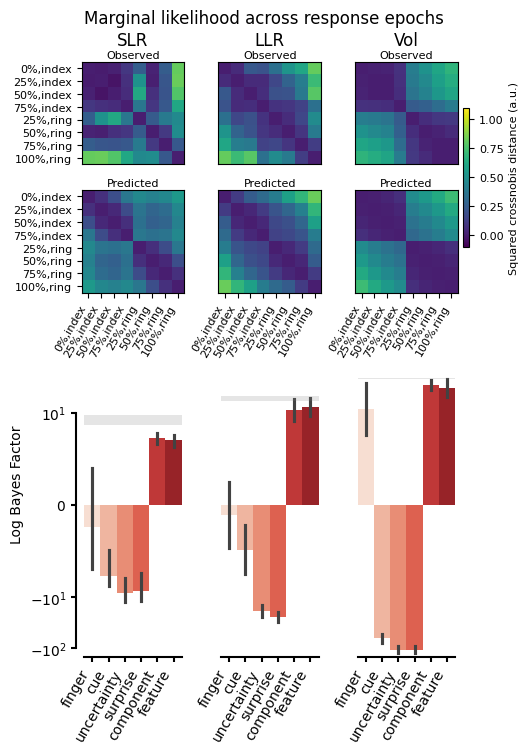

In [27]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 4.5), sharey=True,)

vmin, vmax = -.1, 1.1

for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se')
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_ylim((-150, 10**3))
    ax.spines[['left',]].set_bounds(-10**2, 10)
    ax.set_yticks([-10**2, -10, 0, 10, ])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
    ax.tick_params(axis='y', which='minor', left=False)

    ax.set_xlim(-1, 6)
    ax.spines[['bottom',]].set_bounds(-.5, 5.5)

    ax.set_title(f'{epoch}', pad=12)

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.{epoch}.pkl'), "rb")
    theta = pickle.load(f)
    theta_f = theta[idxf][:Mf.n_param]

    Df = []
    for i in range(theta_f.shape[1]):
        G_hat_f, _ = Mf.predict(theta_f[:, i])
        Df.append(pcm.G_to_dist(G_hat_f / np.trace(G_hat_f)))

    insetx = .05
    insety = (1.05, 1.42)
    insetw = .9
    inseth = .3
    cbarc = (insety[0] + insety[1] + inseth) / 2
    cbarx = 1
    cbarw = 0.4

    # Create first inset (upper)
    inset1 = ax.inset_axes([insetx, insety[1], insetw, inseth], transform=ax.transAxes)  # [x0, y0, width, height]
    cax = inset1.imshow(D_obs, vmin=vmin, vmax=vmax)  # Replace with your plotting code for the first inset
    inset1.set_xticks([])
    inset1.set_yticks([])
    inset1.set_title('Observed', fontsize=8, pad=3)
    if r==0:
        inset1.set_yticks(np.arange(8))
        inset1.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

    # Create second inset (just below the first)
    inset2 = ax.inset_axes([insetx, insety[0], insetw, inseth], transform=ax.transAxes)
    inset2.imshow(np.array(Df).mean(axis=0), vmin=vmin, vmax=vmax)
    inset2.set_title('Predicted', fontsize=8, pad=3)
    inset2.set_xticks(np.arange(8))
    inset2.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    inset2.set_yticks([])
    if r==0:
        inset2.set_yticks(np.arange(8))
        inset2.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8,)

    # Add colorbar
    if r == len(epochs) - 1:
        cbar_ax = ax.inset_axes([cbarx, cbarc-cbarw/2, 0.05, cbarw], transform=ax.transAxes)  # [left, bottom, width, height] in figure coordinates
        cbar = fig.colorbar(cax, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Squared crossnobis distance (a.u.)', fontsize=8)

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')

    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

fig.suptitle('Marginal likelihood across response epochs',y=1.55)

# fig.tight_layout()

save_figure_incremental(fig, 'ml_emg')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/comp_model_coeff_emg_2.svg


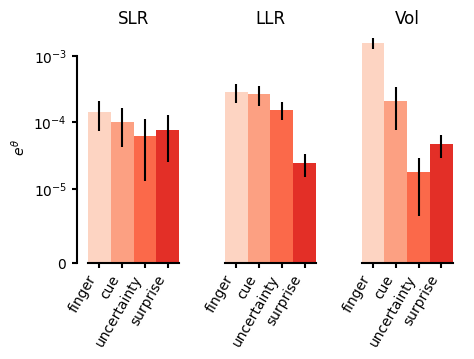

In [28]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

components = ['finger', 'cue', 'uncertainty', 'surprise']

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'component')

n_param = M.n_param

fig, axs = plt.subplots(1, len(epochs),sharey=True, figsize=(5, 3), )

colors = sns.color_palette("Reds", n_colors=5)[:4]

for r, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_yscale('symlog', linthresh=1e-5)
    axs[r].set_title(f'{epoch}')
    axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
    axs[r].set_xlim(-1, 4)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].spines[['left',]].set_bounds(0, 10**-3)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

save_figure_incremental(fig, 'comp_model_coeff_emg')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/feat_model_coeff_emg_5.svg


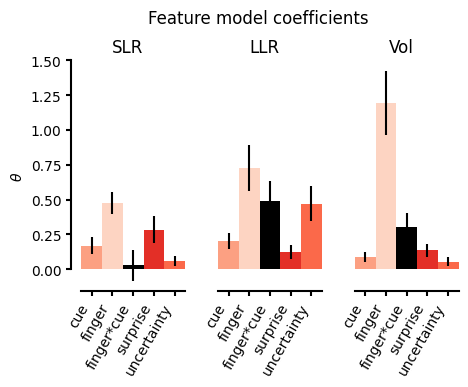

In [34]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

features = ['finger', 'cue', 'uncertainty', 'surprise', 'finger*cue']

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

n_param = M.n_param

fig, axs = plt.subplots(1, len(epochs),sharey=True, figsize=(5, 3), )

colors = sns.color_palette("Reds", n_colors=5)[:4] + [(0, 0, 0)]

for r, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.pkl'), "rb")
    theta = pickle.load(f)[idx][:n_param]

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    features = np.array(features)
    idxs = np.array([0, 1, -1, 2, 3])
    order = np.argsort(features[idxs])
    axs[r].bar(features[idxs][order], theta_avg[idxs][order], width=1, yerr=theta_err[idxs][order], facecolor=np.array(colors)[idxs][order])
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    # axs[r].set_yscale('symlog', linthresh=1e-5)
    axs[r].set_title(f'{epoch}')
    axs[r].spines[['bottom',]].set_bounds(-.5, 4.5)
    axs[r].set_xlim(-1, 4.5)

    if r == 0:
        axs[r].set_ylabel(r'$\theta$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].spines[['left',]].set_bounds(0, 1.5)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

fig.suptitle('Feature model coefficients', y=1.05)

save_figure_incremental(fig, 'feat_model_coeff_emg')

plt.show()